In [1]:
from analyzer import * 
import seaborn as sns 

sns.set_theme(
    style="whitegrid",
    context="paper",
) 

vv = VQAResults()   
human_vqa = vv.human 
model_vqa = vv.model 

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


   Loading VQA annotations from /home/work/yuna/data/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
13 7
[]
[]


In [ ]:
mm = MMStarResults()
model_mmstar = mm.model

In [6]:
vv.model.condition.unique()

array(['inst blind'], dtype=object)

In [7]:
vv.model.columns

Index(['image_id', 'question_id', 'question_type', 'question', 'answers',
       'multiple_choice_answer', 'answer_type', 'pid', 'output',
       'processed_ans', 'answer_similarity', 'correct', 'filename', 'model',
       'trained_dataset', 'strategy', 'blind', 'condition', 'meta_model',
       'model_raw', 'family', 'model_size', 'finetuned', 'model_type'],
      dtype='object')

In [ ]:
integrate_agreement_matrices(res_HH, res_MM, res_HM) 

In [4]:
vv.human.columns

Index(['﻿question_num', 'question_id', 'answer', 'confidence',
       'time_spent_seconds', 'answer_timestamp', 'participant_id', 'question',
       'answer_type', 'answer_original', 'answer_raw', 'answer_normalized',
       'correct', 'answer_similarity', 'gt_answers', 'visual_gt', 'model',
       'meta_model', 'condition', 'question_type', 'new_question_type',
       'processed_ans'],
      dtype='object')

In [10]:
vv.human['answer_similarity'] = vv.human['answer_similarity']*100

In [16]:
vm = vv.model
vm = vm[vm['finetuned'] == 'Pretrained']

In [26]:
vm.finetuned.unique()

array(['Pretrained'], dtype=object)

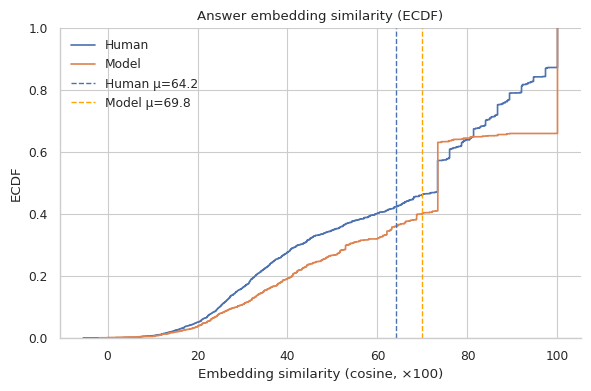

In [32]:
draw_ecdf_embedding_similarity(vv.human['answer_similarity'], vm['answer_similarity']) 

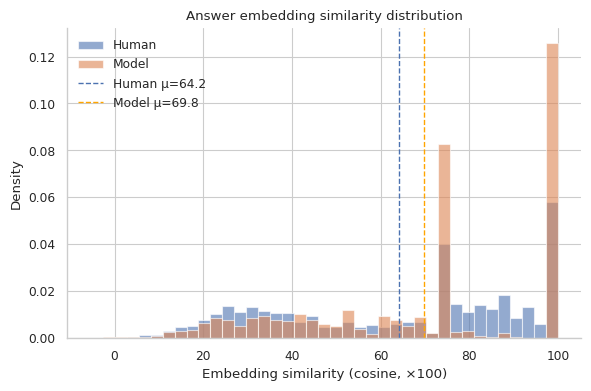

In [31]:
draw_histogram_embedding_similarity(vv.human['answer_similarity'], vm['answer_similarity'])


In [29]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


def draw_histogram_embedding_similarity(human, model, save=None):
    plt.figure(figsize=(6, 4))

    # Shared bins for fair comparison
    bins = np.linspace(
        min(human.min(), model.min()),
        max(human.max(), model.max()),
        40
    )

    plt.hist(
        human, bins=bins, alpha=0.6, density=True,
        label="Human"
    )
    plt.hist(
        model, bins=bins, alpha=0.6, density=True,
        label="Model"
    )

    # Mean lines
    plt.axvline(
        human.mean(), ls="--", lw=1,
        label=f"Human μ={human.mean():.1f}"
    )
    plt.axvline(
        model.mean(), ls="--", lw=1, color="orange",
        label=f"Model μ={model.mean():.1f}"
    )

    plt.xlabel("Embedding similarity (cosine, ×100)")
    plt.ylabel("Density")
    plt.title("Answer embedding similarity distribution")
    plt.legend(frameon=False)

    sns.despine()
    plt.tight_layout()

    if save is not None:
        plt.savefig(save, dpi=300, bbox_inches="tight")
    else:
        plt.show()


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns


def draw_ecdf_embedding_similarity(human, model, save=None):
    plt.figure(figsize=(6, 4))

    # ECDF curves
    sns.ecdfplot(human, label="Human")
    sns.ecdfplot(model, label="Model")

    # Mean lines
    plt.axvline(
        human.mean(), ls="--", lw=1,
        label=f"Human μ={human.mean():.1f}"
    )
    plt.axvline(
        model.mean(), ls="--", lw=1, color="orange",
        label=f"Model μ={model.mean():.1f}"
    )

    plt.xlabel("Embedding similarity (cosine, ×100)")
    plt.ylabel("ECDF")
    plt.title("Answer embedding similarity (ECDF)")
    plt.legend(frameon=False)

    sns.despine()
    plt.tight_layout()

    if save is not None:
        plt.savefig(save, dpi=300, bbox_inches="tight")
    else:
        plt.show()


In [ ]:
vv.human.answer_type.unique() # , vv.model 

array(['yes/no', 'number', 'other'], dtype=object)

In [ ]:
md[(md['finetuned'] == 'Pretrained') & (md['category'] != 'science & technology')].pivot_table(index=['model'], columns=['category'], values=['correct'], 
    margins=True,
    margins_name='Average' ).to_latex('./tables/1_mmstar_blind.tex', float_format="%.1f")      

In [99]:
results = pd.merge(df.groupby(["category",	"l2_category"]).agg({'correct': 'mean', 'question':'nunique'}).reset_index(),
        blind.groupby(["category",	"l2_category"])['correct'].mean().reset_index(), 
        on=["category",	"l2_category"], suffixes=('_human', '_model')
        )
        
results['diff'] = np.abs(results['correct_model'] - results['correct_human'])
results.sort_values(by=['diff']) 

,category,l2_category,correct_human,question,correct_model,diff
8,instance reasoning,single-instance reasoning,0.343750,4,0.340909,0.002841
13,math,numeric commonsense and calculation,0.250000,1,0.242857,0.007143
10,logical reasoning,common reasoning,0.240385,13,0.232877,0.007508
3,fine-grained perception,localization,0.125000,1,0.083333,0.041667
2,coarse perception,image style & quality,0.250000,2,0.291667,0.041667
0,coarse perception,image emotion,0.375000,4,0.289474,0.085526
15,science & technology,biology & chemistry & physics,0.187500,2,0.100000,0.087500
5,fine-grained perception,recognition,0.321429,7,0.208333,0.113095
11,logical reasoning,diagram reasoning,0.166667,6,0.280488,0.113821
12,math,geometry,0.270000,25,0.390000,0.120000
